# Project 1 — XGBoost
## Customer Purchase Prediction

Predicting whether a website visitor will make a purchase based on page views, time on site, previous purchases, and email engagement.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report,
                              roc_auc_score, roc_curve)
np.random.seed(42)
pd.set_option('display.max_columns', None)


## 1. Generate / Load Data

In [2]:
n = 900
will_purchase = np.random.choice([0,1], n, p=[0.7,0.3])
page_views = np.where(will_purchase==1, np.random.poisson(12,n), np.random.poisson(4,n))
time_on_site = np.where(will_purchase==1, np.random.gamma(4,3,n), np.random.gamma(2,2,n))
previous_purchases = np.where(will_purchase==1, np.random.poisson(2,n), np.random.poisson(0.3,n))
email_opens = np.where(will_purchase==1, np.random.poisson(3,n), np.random.poisson(0.8,n))

df = pd.DataFrame({'page_views': page_views, 'time_on_site': time_on_site,
                    'previous_purchases': previous_purchases, 'email_opens': email_opens,
                    'will_purchase': will_purchase})
df.head()


,page_views,time_on_site,previous_purchases,email_opens,will_purchase
0,5,3.514399,0,1,0
1,8,10.312162,0,4,1
2,11,15.576189,1,1,1
3,2,0.784825,3,0,0
4,5,2.520267,1,0,0


## 2. Preprocessing

In [3]:
X = df.drop('will_purchase', axis=1)
y = df['will_purchase']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


## 3. Train Model

In [4]:
from xgboost import XGBClassifier

model = XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=4,
                       subsample=0.8, colsample_bytree=0.8,
                       reg_alpha=0.1, reg_lambda=1.0,
                       eval_metric='logloss', random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


## 4. Evaluate

In [5]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted', zero_division=0))
print("Recall:", recall_score(y_test, y_pred, average='weighted', zero_division=0))
print("F1:", f1_score(y_test, y_pred, average='weighted', zero_division=0))
print()
print(classification_report(y_test, y_pred, zero_division=0))


Accuracy: 0.9722222222222222
Precision: 0.9724017094017096
Recall: 0.9722222222222222
F1: 0.9719798185855381

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       127
           1       0.98      0.92      0.95        53

    accuracy                           0.97       180
   macro avg       0.97      0.96      0.97       180
weighted avg       0.97      0.97      0.97       180



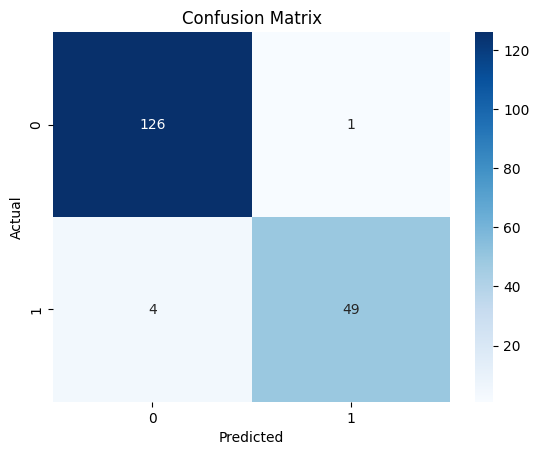

In [6]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix')
plt.show()


## Takeaways
- Check `model.feature_importances_` — previous_purchases and email_opens likely dominate (strong intent signals).
- Try `xgboost.plot_importance(model)` for a built-in visualization.
- Next steps: add an eval_set with `early_stopping_rounds` to auto-select the best n_estimators instead of guessing.

---
# Project 2 — Your Turn
**Dataset:** MPG dataset (`seaborn.load_dataset('mpg')`) — predict car `origin` (usa/europe/japan) from mpg, horsepower, weight, cylinders, etc.

```python
import seaborn as sns
mpg = sns.load_dataset('mpg')
```
**Tasks:** handle missing values, encode the target, train XGBoost for multi-class classification, evaluate, and check feature importances.
